In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Q_1

## implement code without predefined functions for Transformer algorithm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
import gzip
import matplotlib.pyplot as plt

# Custom Dataset Class
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sequence, label = self.sequences[index]
        return sequence, label

# Create Sequences for Training
def create_sequences(data, input_length=96, horizon=96):
    sequences = []
    data_size = len(data)
    for i in range(data_size - input_length - horizon):
        input_seq = torch.tensor(data[i:i+input_length], dtype=torch.float32)
        target_seq = torch.tensor(data[i+input_length:i+input_length+horizon], dtype=torch.float32)
        sequences.append((input_seq, target_seq))
    return sequences

# Load and Preprocess the Data
def load_and_preprocess_data(file_path):
    with gzip.open(file_path, 'rt') as file:
        df = pd.read_csv(file)
    df = df.ffill()
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(df)
    return data_scaled, scaler

# Scaled Dot Product Attention
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.scale = 1.0 / np.sqrt(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value):
        scores = torch.matmul(query, key.transpose(-2, -1)) * self.scale
        attention = torch.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        output = torch.matmul(attention, value)
        return output

# Multi-head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        assert self.head_dim * nhead == self.d_model, "d_model must be divisible by nhead"

        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(self.head_dim, dropout)

    def forward(self, query, key, value):
        batch_size = query.size(0)
        query = self.query(query).view(batch_size, -1, self.nhead, self.head_dim).transpose(1, 2)
        key = self.key(key).view(batch_size, -1, self.nhead, self.head_dim).transpose(1, 2)
        value = self.value(value).view(batch_size, -1, self.nhead, self.head_dim).transpose(1, 2)

        # Apply attention
        attention = self.attention(query, key, value)
        attention = attention.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        output = self.fc(attention)
        return output

# Feed Forward Network
class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = self.dropout(x)
        x = self.linear2(x)
        return x

# Transformer Block (Encoder)
class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, nhead, dropout)
        self.feed_forward = FeedForwardNetwork(d_model, dim_feedforward, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # Multi-head attention part
        att_output = self.attention(src, src, src)
        src = self.norm1(src + self.dropout(att_output))
        # Feedforward part
        ff_output = self.feed_forward(src)
        src = self.norm2(src + self.dropout(ff_output))
        return src

# Transformer Model using custom blocks
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, horizon, dropout=0.1):
        super().__init__()
        self.input_emb = nn.Linear(input_size, d_model)
        self.positional_encoding = nn.Parameter(torch.zeros(1, d_model))
        self.layers = nn.ModuleList([TransformerBlock(d_model, nhead, d_model * 2, dropout) for _ in range(num_layers)])
        self.fc_out = nn.Linear(d_model, input_size * horizon)
        self.horizon = horizon
        self.input_size = input_size

    def forward(self, src):
        src = self.input_emb(src) + self.positional_encoding
        for layer in self.layers:
            src = layer(src)
        output = self.fc_out(src[:, -1, :])
        output = output.view(src.size(0), self.horizon, self.input_size)
        return output

# Training and Evaluation Function
def train_and_evaluate_model(model, train_loader, test_loader, epochs, optimizer, criterion, device, horizon, scaler, plot_length=20000):
    model.train()
    train_losses = []
    test_losses = []
    for epoch in range(epochs):
        total_loss = 0
        for sequences, labels in train_loader:
            sequences, labels = sequences.to(device).float(), labels.to(device).float()
            optimizer.zero_grad()
            output = model(sequences)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        epoch_loss = total_loss / len(train_loader)
        train_losses.append(epoch_loss)
        print(f"Horizon {horizon} - Epoch {epoch+1}, Training Loss: {epoch_loss}")

        # Evaluate on the test set
        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for sequences, labels in test_loader:
                sequences, labels = sequences.to(device).float(), labels.to(device).float()
                output = model(sequences)
                test_loss = criterion(output, labels)
                total_test_loss += test_loss.item()
        test_epoch_loss = total_test_loss / len(test_loader)
        test_losses.append(test_epoch_loss)

    # Plot the training and test losses
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'Training and Test Loss for Horizon {horizon}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot a subset of Actual vs. Predicted values for the last epoch of train and test sets
    model.eval()
    with torch.no_grad():
        # For Train Set
        actuals, predictions = [], []
        for sequences, labels in train_loader:
            sequences, labels = sequences.to(device).float(), labels.to(device).float()
            output = model(sequences)
            actuals.extend(labels.cpu().numpy())
            predictions.extend(output.cpu().numpy())
        plt.figure(figsize=(10, 6))
        actual_index = max(0, len(actuals) - plot_length)
        plt.plot(np.array(actuals)[actual_index:].flatten(), label='Actual')
        plt.plot(np.array(predictions)[actual_index:].flatten(), label='Predicted', linestyle='--')
        plt.title(f'Actual vs Predicted - Train Set for Horizon {horizon}')
        plt.legend()
        plt.grid(True)
        plt.show()

        # For Test Set
        actuals, predictions = [], []
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device).float(), labels.to(device).float()
            output = model(sequences)
            actuals.extend(labels.cpu().numpy())
            predictions.extend(output.cpu().numpy())
        plt.figure(figsize=(10, 6))
        actual_index = max(0, len(actuals) - plot_length)
        plt.plot(np.array(actuals)[actual_index:].flatten(), label='Actual')
        plt.plot(np.array(predictions)[actual_index:].flatten(), label='Predicted', linestyle='--')
        plt.title(f'Actual vs Predicted - Test Set for Horizon {horizon}')
        plt.legend()
        plt.grid(True)
        plt.show()

    return test_epoch_loss


# Main Script for Multiple Horizons
if __name__ == "__main__":
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load and preprocess data
    file_path = '/content/drive/MyDrive/machine learning - bouns peoject/exchange_rate.txt.gz'
    data_scaled, scaler = load_and_preprocess_data(file_path)

    # Define horizons
    horizons = [96, 192, 336, 720]
    test_results = {}

    for horizon in horizons:
        print(f"\nTraining for Horizon: {horizon}")

        # Create sequences with input length 96 and the current horizon
        sequences = create_sequences(data_scaled, input_length=96, horizon=horizon)
        train_size = int(len(sequences) * 0.7)
        train_sequences, test_sequences = sequences[:train_size], sequences[train_size:]

        # Create DataLoaders
        train_dataset = TimeSeriesDataset(train_sequences)
        test_dataset = TimeSeriesDataset(test_sequences)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

        # Initialize model, optimizer, and loss function
        model = TransformerModel(input_size=data_scaled.shape[1], d_model=64, nhead=4, num_layers=4, horizon=horizon).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        criterion = nn.MSELoss()

        # Train and evaluate the model
        test_loss = train_and_evaluate_model(
            model, train_loader, test_loader, epochs=40,
            optimizer=optimizer, criterion=criterion, device=device, horizon=horizon, scaler=scaler
        )
        test_results[horizon] = {"Test Loss (MSE)": test_loss}

    # Print test results
    print("\nFinal Test Results:")
    for horizon, metrics in test_results.items():
        print(f"Horizon {horizon}: Test Loss (MSE) = {metrics['Test Loss (MSE)']:.6f}")



Training for Horizon: 96
Horizon 96 - Epoch 1, Training Loss: 0.2522845846819289
Horizon 96 - Epoch 2, Training Loss: 0.06739987534137419
Horizon 96 - Epoch 3, Training Loss: 0.03555802789367275
Horizon 96 - Epoch 4, Training Loss: 0.028953465253666596
Horizon 96 - Epoch 5, Training Loss: 0.025723972254329257
Horizon 96 - Epoch 6, Training Loss: 0.022611277430881687
Horizon 96 - Epoch 7, Training Loss: 0.019674913842736938
Horizon 96 - Epoch 8, Training Loss: 0.017213047585553594
Horizon 96 - Epoch 9, Training Loss: 0.015273897023296651
Horizon 96 - Epoch 10, Training Loss: 0.013704314126552623
Horizon 96 - Epoch 11, Training Loss: 0.012389738009207778
Horizon 96 - Epoch 12, Training Loss: 0.011222647824957048
Horizon 96 - Epoch 13, Training Loss: 0.010131370770618504
Horizon 96 - Epoch 14, Training Loss: 0.009140794349397406
Horizon 96 - Epoch 15, Training Loss: 0.008313700671733162
Horizon 96 - Epoch 16, Training Loss: 0.007471744454017392
Horizon 96 - Epoch 17, Training Loss: 0.006

In [ ]:
!pip install torch torchvision


##seccond iTransformer implementation (inspired on github-code)

In [ ]:
!pip install utils

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=42e4487fe9018d484ec047d2d577179adec22a6b5c93f3f912d1893b42622bb2
  Stored in directory: /root/.cache/pip/wheels/15/0c/b3/674aea8c5d91c642c817d4d630bd58faa316724b136844094d
Successfully built utils


In [ ]:
%cd /content/drive/MyDrive/machine learning - bouns peoject/iTransformer-main/iTransformer-main


In [ ]:
!python setup.py install


running install
/usr/local/lib/python3.11/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.11/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https

In [ ]:
import utils


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/drive/MyDrive/machine learning - bouns peoject/exchange_rate.txt.gz'
data = pd.read_csv(file_path, compression='gzip')

# Preprocessing: Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Normalize the data
scaled_data = scaler.fit_transform(data)

# Split data into training and testing sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.7)
train_scaled = scaled_data[:train_size]
test_scaled = scaled_data[train_size:]

# Prepare the data by creating time series windows for forecasting
seq_len = 500
pred_len = 192

def create_time_series_windows(data, seq_len, pred_len):
    x_enc = []
    x_dec = []
    for i in range(len(data) - seq_len - pred_len + 1):
        x_enc.append(data[i:i+seq_len])  # Input sequence
        x_dec.append(data[i+seq_len:i+seq_len+pred_len])
    return np.array(x_enc), np.array(x_dec)

# Apply to the train and test data
train_x, train_y = create_time_series_windows(train_scaled, seq_len, pred_len)
test_x, test_y = create_time_series_windows(test_scaled, seq_len, pred_len)

# Convert to tensors
train_x = torch.tensor(train_x, dtype=torch.float32)
train_y = torch.tensor(train_y, dtype=torch.float32)
test_x = torch.tensor(test_x, dtype=torch.float32)
test_y = torch.tensor(test_y, dtype=torch.float32)

# Check the shape of the data
print(f"train_x shape: {train_x.shape}, train_y shape: {train_y.shape}")
print(f"test_x shape: {test_x.shape}, test_y shape: {test_y.shape}")

# Custom Transformer Components

class EncoderLayer(nn.Module):
    def __init__(self, attention, d_model, d_ff=None, dropout=0.1, activation="relu"):
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, attn_mask=None, tau=None, delta=None):
        new_x, attn = self.attention(x, x, x, attn_mask=attn_mask, tau=tau, delta=delta)
        x = x + self.dropout(new_x)

        y = x = self.norm1(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))

        return self.norm2(x + y), attn


class Encoder(nn.Module):
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super(Encoder, self).__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers is not None else None
        self.norm = norm_layer

    def forward(self, x, attn_mask=None, tau=None, delta=None):
        attns = []
        if self.conv_layers is not None:
            for i, (attn_layer, conv_layer) in enumerate(zip(self.attn_layers, self.conv_layers)):
                delta = delta if i == 0 else None
                x, attn = attn_layer(x, attn_mask=attn_mask, tau=tau, delta=delta)
                x = conv_layer(x)
                attns.append(attn)
            x, attn = self.attn_layers[-1](x, tau=tau, delta=None)
            attns.append(attn)
        else:
            for attn_layer in self.attn_layers:
                x, attn = attn_layer(x, attn_mask=attn_mask, tau=tau, delta=delta)
                attns.append(attn)

        if self.norm is not None:
            x = self.norm(x)

        return x, attns


class DataEmbedding_inverted(nn.Module):
    def __init__(self, time_steps, d_model, dropout=0.1):
        super(DataEmbedding_inverted, self).__init__()
        self.value_embedding = nn.Linear(time_steps, d_model)  # This expects [batch_size, time_steps]
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = x.squeeze(-1)  # Assuming x is [batch, time_steps, 1]
        x = self.value_embedding(x)  # Now x should be [batch, d_model]
        x = self.dropout(x)
        x = x.unsqueeze(1)
        return x



class FullAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None, attention_dropout=0.1, output_attention=False):
        super(FullAttention, self).__init__()
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def forward(self, queries, keys, values, attn_mask=None, tau=None, delta=None):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1. / sqrt(E)

        scores = torch.einsum("blhe,bshe->bhls", queries, keys)

        if self.mask_flag:
            if attn_mask is None:
                # Create a lower triangular matrix as the causal mask
                attn_mask = torch.tril(torch.ones(L, S, device=queries.device)).bool()

            scores = scores.masked_fill(~attn_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        A = self.dropout(torch.softmax(scale * scores, dim=-1))
        V = torch.einsum("bhls,bshd->blhd", A, values)

        if self.output_attention:
            return (V.contiguous(), A)
        else:
            return (V.contiguous(), None)

class AttentionLayer(nn.Module):
    def __init__(self, attention, d_model, n_heads, d_keys=None,
                 d_values=None):
        super(AttentionLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)

        self.inner_attention = attention
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)

        out, attn = self.inner_attention(
            queries,
            keys,
            values,
            attn_mask,
            tau=tau,
            delta=delta
        )
        out = out.view(B, L, -1)

        return self.out_projection(out), attn


# Main Model: iTransformer
class Model(nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.output_attention = configs.output_attention
        self.use_norm = configs.use_norm
        # Embedding
        self.enc_embedding = DataEmbedding_inverted(configs.seq_len, configs.d_model, configs.embed, configs.freq,
                                                    configs.dropout)
        self.class_strategy = configs.class_strategy
        # Encoder-only architecture
        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(
                        FullAttention(False, configs.factor, attention_dropout=configs.dropout,
                                      output_attention=configs.output_attention), configs.d_model, configs.n_heads),
                    configs.d_model,
                    configs.d_ff,
                    dropout=configs.dropout,
                    activation=configs.activation
                ) for l in range(configs.e_layers)
            ],
            norm_layer=torch.nn.LayerNorm(configs.d_model)
        )
        self.projector = nn.Linear(configs.d_model, configs.pred_len, bias=True)

    def forecast(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        if self.use_norm:
            means = x_enc.mean(1, keepdim=True).detach()
            x_enc = x_enc - means
            stdev = torch.sqrt(torch.var(x_enc, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x_enc /= stdev

        _, _, N = x_enc.shape

        enc_out = self.enc_embedding(x_enc, x_mark_enc)
        enc_out, attns = self.encoder(enc_out, attn_mask=None)

        dec_out = self.projector(enc_out).permute(0, 2, 1)[:, :, :N]

        if self.use_norm:
            dec_out = dec_out * (stdev[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))
            dec_out = dec_out + (means[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))

        return dec_out

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        dec_out = self.forecast(x_enc, x_mark_enc, x_dec, x_mark_dec)
        return dec_out[:, -self.pred_len:, :]


# Example configurations for the model
class Configs:
    seq_len = 500
    pred_len = 192
    d_model = 64
    n_heads = 4
    d_ff = 256
    e_layers = 3
    dropout = 0.1
    embed = 'fixed'
    freq = 'h'
    output_attention = False
    use_norm = True
    activation = 'relu'
    class_strategy = 'classification'
    factor = 5


# Instantiate the model
configs = Configs()
model = Model(configs)

# Training loop (example)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()
# Store loss values for plotting
train_losses = []
test_losses = []

# Training the model
for epoch in range(100):  # Example number of epochs
    model.train()
    optimizer.zero_grad()

    # Forward pass
    output_train = model(train_x, None, train_x, None)

    # Compute training loss
    train_loss = criterion(output_train, train_y)
    train_losses.append(train_loss.item())

    # Backward pass and update model parameters
    train_loss.backward()
    optimizer.step()

    # Compute testing loss (for validation)
    model.eval()
    with torch.no_grad():
        output_test = model(test_x, None, test_x, None)
        test_loss = criterion(output_test, test_y)
        test_losses.append(test_loss.item())

    # Print loss for every epoch
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

# Plot training and testing loss over epochs
plt.plot(range(1, 101), train_losses, label="Train Loss")
plt.plot(range(1, 101), test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Testing Loss")
plt.show()


#'/content/drive/MyDrive/machine learning - bouns peoject/exchange_rate.txt.gz'

##Flash Attention

Epoch [10/100], Train Loss: 0.3231, Test Loss: 0.2049
Epoch [20/100], Train Loss: 0.2468, Test Loss: 0.1717
Epoch [30/100], Train Loss: 0.2082, Test Loss: 0.1558
Epoch [40/100], Train Loss: 0.1880, Test Loss: 0.1415
Epoch [50/100], Train Loss: 0.1760, Test Loss: 0.1506
Epoch [60/100], Train Loss: 0.1672, Test Loss: 0.1441
Epoch [70/100], Train Loss: 0.1602, Test Loss: 0.1438
Epoch [80/100], Train Loss: 0.1534, Test Loss: 0.1397
Epoch [90/100], Train Loss: 0.1485, Test Loss: 0.1455
Epoch [100/100], Train Loss: 0.1433, Test Loss: 0.1444


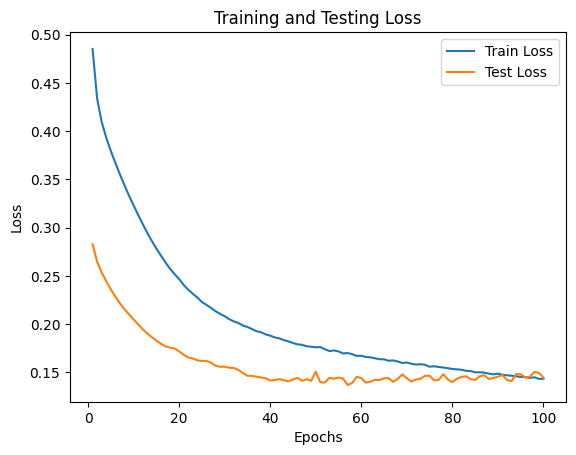

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Assuming FlashAttention is custom and needs definition
class FlashAttention(nn.Module):
    def __init__(self, mask_flag=True, scale=None, attention_dropout=0.1, output_attention=False):
        super(FlashAttention, self).__init__()
        self.scale = scale or 1.0
        self.mask_flag = mask_flag
        self.dropout = nn.Dropout(attention_dropout)
        self.output_attention = output_attention

    def forward(self, queries, keys, values, attn_mask=None):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1. / sqrt(E)

        scores = torch.matmul(queries, keys.transpose(-2, -1)) * scale

        if attn_mask is not None and self.mask_flag:
            scores = scores.masked_fill(attn_mask == 0, float('-inf'))

        attention = torch.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        output = torch.matmul(attention, values)

        if self.output_attention:
            return output, attention
        return output, None

# Placeholder for the data loading and preprocessing
# Load the dataset
file_path = '/content/drive/MyDrive/machine learning - bouns peoject/exchange_rate.txt.gz'
data = pd.read_csv(file_path, compression='gzip')

# Preprocessing: Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Split data into training and testing sets
train_size = int(len(scaled_data) * 0.7)
train_scaled = scaled_data[:train_size]
test_scaled = scaled_data[train_size:]

# Function to create time series windows
def create_time_series_windows(data, seq_len, pred_len):
    x_enc = []
    x_dec = []
    for i in range(len(data) - seq_len - pred_len + 1):
        x_enc.append(data[i:i+seq_len])  # Input sequence
        x_dec.append(data[i+seq_len:i+seq_len+pred_len])
    return np.array(x_enc), np.array(x_dec)

# Create time series windows
seq_len = 500
pred_len = 192
train_x, train_y = create_time_series_windows(train_scaled, seq_len, pred_len)
test_x, test_y = create_time_series_windows(test_scaled, seq_len, pred_len)

# Convert to tensors
train_x = torch.tensor(train_x, dtype=torch.float32)
train_y = torch.tensor(train_y, dtype=torch.float32)
test_x = torch.tensor(test_x, dtype=torch.float32)
test_y = torch.tensor(test_y, dtype=torch.float32)

# Custom Transformer Components including FlashAttention
class AttentionLayer(nn.Module):
    def __init__(self, attention, d_model, n_heads, d_keys=None, d_values=None):
        super(AttentionLayer, self).__init__()
        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)
        self.inner_attention = attention
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads
        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)
        out, attn = self.inner_attention(queries, keys, values, attn_mask)
        out = out.view(B, L, -1)
        return self.out_projection(out), attn

# Main Model with FlashAttention
class Model(nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.output_attention = configs.output_attention
        self.use_norm = configs.use_norm
        self.enc_embedding = DataEmbedding_inverted(configs.seq_len, configs.d_model, configs.embed, configs.freq, configs.dropout)
        self.encoder = Encoder([EncoderLayer(AttentionLayer(FlashAttention(False, configs.factor, attention_dropout=configs.dropout, output_attention=configs.output_attention), configs.d_model, configs.n_heads), configs.d_model, configs.d_ff, dropout=configs.dropout, activation=configs.activation) for _ in range(configs.e_layers)], norm_layer=torch.nn.LayerNorm(configs.d_model))
        self.projector = nn.Linear(configs.d_model, configs.pred_len, bias=True)

    def forecast(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        if self.use_norm:
            means = x_enc.mean(1, keepdim=True).detach()
            x_enc = x_enc - means
            stdev = torch.sqrt(torch.var(x_enc, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x_enc /= stdev

        _, _, N = x_enc.shape
        enc_out = self.enc_embedding(x_enc, x_mark_enc)
        enc_out, attns = self.encoder(enc_out, attn_mask=None)
        dec_out = self.projector(enc_out).permute(0, 2, 1)[:, :, :N]

        if self.use_norm:
            dec_out = dec_out * (stdev[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))
            dec_out = dec_out + (means[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))

        return dec_out

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        dec_out = self.forecast(x_enc, x_mark_enc, x_dec, x_mark_dec)
        return dec_out[:, -self.pred_len:, :]

# Configuration and model instantiation
configs = Configs()
model = Model(configs)

# Define the training loop and evaluation
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()
train_losses = []
test_losses = []

for epoch in range(100):  # Number of epochs
    model.train()
    optimizer.zero_grad()
    output_train = model(train_x, None, train_x, None)
    train_loss = criterion(output_train, train_y)
    train_losses.append(train_loss.item())
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        output_test = model(test_x, None, test_x, None)
        test_loss = criterion(output_test, test_y)
        test_losses.append(test_loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

plt.plot(range(1, 101), train_losses, label="Train Loss")
plt.plot(range(1, 101), test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Testing Loss")
plt.show()


Starting Fold 1
Epoch 1: Train Loss = 0.0123, Test Loss = 0.0017
Epoch 2: Train Loss = 0.0036, Test Loss = 0.0027
Epoch 3: Train Loss = 0.0031, Test Loss = 0.0029
Epoch 4: Train Loss = 0.0031, Test Loss = 0.0023
Epoch 5: Train Loss = 0.0029, Test Loss = 0.0015
Epoch 6: Train Loss = 0.0027, Test Loss = 0.0018
Epoch 7: Train Loss = 0.0028, Test Loss = 0.0016
Epoch 8: Train Loss = 0.0026, Test Loss = 0.0017
Epoch 9: Train Loss = 0.0024, Test Loss = 0.0015
Epoch 10: Train Loss = 0.0024, Test Loss = 0.0019
Epoch 11: Train Loss = 0.0018, Test Loss = 0.0013
Epoch 12: Train Loss = 0.0018, Test Loss = 0.0013
Epoch 13: Train Loss = 0.0018, Test Loss = 0.0015
Epoch 14: Train Loss = 0.0018, Test Loss = 0.0014
Epoch 15: Train Loss = 0.0018, Test Loss = 0.0013
Epoch 16: Train Loss = 0.0018, Test Loss = 0.0012
Epoch 17: Train Loss = 0.0018, Test Loss = 0.0015
Epoch 18: Train Loss = 0.0017, Test Loss = 0.0013
Epoch 19: Train Loss = 0.0017, Test Loss = 0.0013
Epoch 20: Train Loss = 0.0017, Test Loss = 

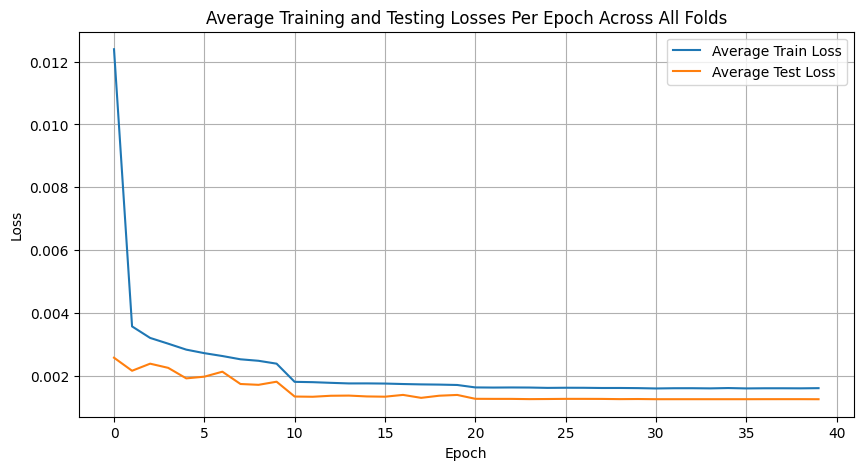

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import math

# Load data
data = pd.read_csv('/content/drive/MyDrive/machine learning - bouns peoject/exchange_rate.txt.gz', header=None)

def create_sequences(data, N, pred_length):
    X, y = [], []
    for feature_index in range(data.shape[1]):
        feature_data = data.iloc[:, feature_index].values
        for i in range(len(feature_data) - N - pred_length + 1):
            X.append(feature_data[i:i+N])
            y.append(feature_data[i+N:i+N+pred_length])
    X = np.array(X).reshape(-1, N, 1)
    y = np.array(y).reshape(-1, pred_length)
    return X, y

N = 96
pred_length = 96
X, y = create_sequences(data, N, pred_length)

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Positional Encoding Module
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        self.pe[:, 0::2] = torch.sin(position * div_term)
        self.pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = self.pe.unsqueeze(0).transpose(0, 1).to(device)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        assert self.head_dim * num_heads == d_model, "d_model must be divisible by num_heads"

        self.linear_k = nn.Linear(d_model, d_model)
        self.linear_v = nn.Linear(d_model, d_model)
        self.linear_q = nn.Linear(d_model, d_model)
        self.softmax = nn.Softmax(dim=-1)
        self.output_layer = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Transform Q, K, V
        q = self.linear_q(q).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.linear_k(k).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.linear_v(v).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        # Attention score calculation
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attention = self.softmax(scores)

        # Attention application on V
        context = torch.matmul(attention, v)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # Final output layer
        output = self.output_layer(context)
        return output


# Custom Embedding Layer
class DataEmbedding_inverted(nn.Module):
    def __init__(self, time_steps, d_model, dropout=0.1):
        super(DataEmbedding_inverted, self).__init__()
        self.value_embedding = nn.Linear(time_steps, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = x.squeeze(-1)
        x = self.value_embedding(x)
        x = x.unsqueeze(1)
        return self.dropout(x)

# Transformer Layer
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, src):
        src2 = self.attention(src, src, src)
        src = self.norm1(src + src2)
        src2 = self.ff(src)
        src = self.norm2(src + src2)
        return src


class Transformer(nn.Module):
    def __init__(self, feature_size, d_model, num_layers, num_heads, d_ff, dropout=0.1):
        super().__init__()
        # Initialize the embedding module using DataEmbedding_inverted
        self.embedding = DataEmbedding_inverted(feature_size, d_model, dropout=dropout)
        self.pos_encoder = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([TransformerEncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.output_layer = nn.Linear(d_model, pred_length)

    def forward(self, src):
        # Apply embedding to the source data
        src = self.embedding(src)
        # Apply positional encoding to the embedded data
        src = self.pos_encoder(src)
        for layer in self.layers:
            src = layer(src)
        src = self.norm(src)
        # The output layer to predict the sequence
        output = self.output_layer(src[:, 0, :])  # Adjust to take the output of the first time step only
        return output

# K-Fold Cross-Validation
def cross_validate(X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_train_losses = []
    all_test_losses = []

    for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
        print(f"Starting Fold {fold}")
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Convert to tensors
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

        # DataLoader
        train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
        test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

        # Initialize model
        model = ITransformer(N, 64, 1, 2, 256).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.MSELoss()
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

        epoch_train_losses = []
        epoch_test_losses = []

        # Training and validation
        for epoch in range (40):
            model.train()
            train_loss = 0
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            train_loss /= len(train_loader)
            epoch_train_losses.append(train_loss)

            model.eval()
            test_loss = 0
            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    test_loss += loss.item()
            test_loss /= len(test_loader)
            epoch_test_losses.append(test_loss)

            print(f"Epoch {epoch + 1}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")

            scheduler.step()

        all_train_losses.append(epoch_train_losses)
        all_test_losses.append(epoch_test_losses)

    return all_train_losses, all_test_losses

# Run cross-validation
all_train_losses, all_test_losses = cross_validate(X, y)

# Calculate the average of the last epoch losses across all folds for final plotting
average_train_losses = np.mean(all_train_losses, axis=0)
average_test_losses = np.mean(all_test_losses, axis=0)

# Plot the losses for each epoch of the last fold
plt.figure(figsize=(10, 5))
plt.plot(average_train_losses, label='Average Train Loss')
plt.plot(average_test_losses, label='Average Test Loss')
plt.title('Average Training and Testing Losses Per Epoch Across All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()





##plot Actual vs predicted

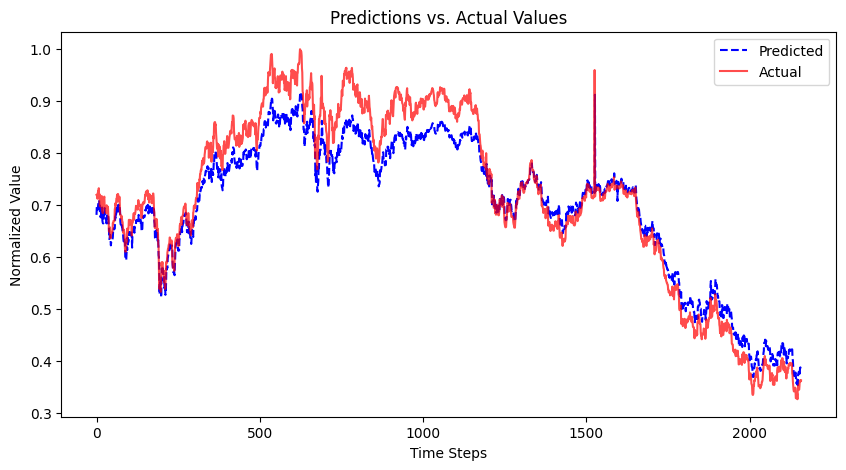

In [ ]:
# Prediction function
def predict(model, test_loader):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            predictions.extend(outputs.numpy())  # Store predictions
            actuals.extend(targets.numpy())  # Store actual values
    return np.array(predictions), np.array(actuals)

# Generate predictions and actuals
predictions, actuals = predict(model, test_loader)

# Plot predictions and actuals
plt.figure(figsize=(10, 5))
plt.plot(predictions, label='Predicted', color='blue', linestyle='--')
plt.plot(actuals, label='Actual', color='red', alpha=0.7)
plt.title('Predictions vs. Actual Values')
plt.xlabel('Time Steps')
plt.ylabel('Normalized Value')
plt.legend()
plt.show()


##iTransformer with 20% variate

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import copy

# Load and preprocess data
def load_data(file_path):
    data = pd.read_csv(file_path, compression='gzip', header=None)
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)
    return data_scaled

# Prepare sequences for training and testing
def create_sequences(data, seq_length, pred_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length - pred_length + 1):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length:i + seq_length + pred_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, src):
        src2 = self.norm1(src)
        src = src + self.self_attn(src2, src2, src2)[0]
        src2 = self.norm2(src)
        src2 = self.linear1(src2)
        src2 = self.dropout(self.linear2(self.dropout(torch.relu(src2))))
        src = src + src2
        return src

class TransformerModel(nn.Module):
    def __init__(self, feature_size, num_layers, num_heads, d_model, dim_feedforward, dropout):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(feature_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.encoder_layer = TransformerEncoderLayer(d_model, num_heads, dim_feedforward, dropout)
        self.transformer_encoder = nn.Sequential(*[copy.deepcopy(self.encoder_layer) for _ in range(num_layers)])
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        src = self.embedding(src)  # [batch, seq_len, feature] -> [batch, seq_len, d_model]
        src = src.permute(1, 0, 2)  # Transformer expects [seq_len, batch, feature]
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        output = output.permute(1, 0, 2)  # Back to [batch, seq_len, d_model]
        output = output[:, -1, :]  # Get last time step
        output = self.decoder(output)  # [batch, 1]
        return output

# Load the data
data_path ='/content/drive/MyDrive/machine learning - bouns peoject/exchange_rate.txt.gz'
data_scaled = load_data(data_path)

# Define sequence and prediction length
seq_length = 100
pred_length = 336  #Horizon [96, 192, 336, 720]

# Create sequences
X, y = create_sequences(data_scaled, seq_length, pred_length)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y[:, 0, 0], dtype=torch.float32)

# K-fold cross-validation setup
kf = KFold(n_splits=5, shuffle=True)
results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_tensor)):
    # Calculate the number of training examples for 20% training data
    train_20_pct_idx = train_idx[:len(train_idx) // 5]  # Use 20% of train_idx for training

    X_train, X_test = X_tensor[train_20_pct_idx], X_tensor[test_idx]
    y_train, y_test = y_tensor[train_20_pct_idx], y_tensor[test_idx]

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Initialize the model
    model = TransformerModel(feature_size=X.shape[2], num_layers=2, num_heads=4, d_model=64, dim_feedforward=256, dropout=0.1)
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.MSELoss()

    # Training loop
    for epoch in range(40):  # You can adjust epochs
        model.train()
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), targets)
                test_loss += loss.item()

        print(f'Fold {fold+1}, Epoch {epoch+1}: Loss = {test_loss/len(test_loader):.4f}')

    # Evaluate the model
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            predictions.extend(outputs.numpy().squeeze())
            actuals.extend(targets.numpy())

    r2 = r2_score(actuals, predictions)
    results.append(r2)
    print(f'Fold {fold+1} R^2: {r2:.4f}')

# Report average performance
average_r2 = np.mean(results)
print(f'Average R^2 across folds: {average_r2:.4f}')


Fold 1, Epoch 1: Loss = 0.0152
Fold 1, Epoch 2: Loss = 0.0147
Fold 1, Epoch 3: Loss = 0.0126
Fold 1, Epoch 4: Loss = 0.0105
Fold 1, Epoch 5: Loss = 0.0110
Fold 1, Epoch 6: Loss = 0.0105
Fold 1, Epoch 7: Loss = 0.0107
Fold 1, Epoch 8: Loss = 0.0120
Fold 1, Epoch 9: Loss = 0.0121
Fold 1, Epoch 10: Loss = 0.0122
Fold 1, Epoch 11: Loss = 0.0135
Fold 1, Epoch 12: Loss = 0.0129
Fold 1, Epoch 13: Loss = 0.0145
Fold 1, Epoch 14: Loss = 0.0155
Fold 1, Epoch 15: Loss = 0.0154
Fold 1, Epoch 16: Loss = 0.0156
Fold 1, Epoch 17: Loss = 0.0165
Fold 1, Epoch 18: Loss = 0.0165
Fold 1, Epoch 19: Loss = 0.0172
Fold 1, Epoch 20: Loss = 0.0166
Fold 1, Epoch 21: Loss = 0.0177
Fold 1, Epoch 22: Loss = 0.0172
Fold 1, Epoch 23: Loss = 0.0177
Fold 1, Epoch 24: Loss = 0.0178
Fold 1, Epoch 25: Loss = 0.0177
Fold 1, Epoch 26: Loss = 0.0171
Fold 1, Epoch 27: Loss = 0.0167
Fold 1, Epoch 28: Loss = 0.0170
Fold 1, Epoch 29: Loss = 0.0176
Fold 1, Epoch 30: Loss = 0.0161
Fold 1, Epoch 31: Loss = 0.0164
Fold 1, Epoch 32:

#Q_2

Processing COVID...
Original shape of jkms-35-e79-g001-l-b.jpg: (341, 417)
Original shape of B59DD164-51D5-40DF-A926-6A42DD52EBE8.jpeg: (1648, 2150)
Original shape of 7E335538-2F86-424E-A0AB-6397783A38D0.jpeg: (3408, 4200)
Original shape of nejmoa2001191_f5-PA.jpeg: (841, 1107)
Original shape of 1-s2.0-S1684118220300608-main.pdf-002.jpg: (500, 508)
Original shape of ards-secondary-to-tiger-snake-bite.png: (795, 927)
Original shape of 7C69C012-7479-493F-8722-ABC29C60A2DD.jpeg: (1243, 1249)
Original shape of 1B734A89-A1BF-49A8-A1D3-66FAFA4FAC5D.jpeg: (1403, 1696)
Original shape of 2C26F453-AF3B-4517-BB9E-802CF2179543.jpeg: (1447, 1884)
Original shape of all14238-fig-0001-m-b.jpg: (708, 629)
Original shape of kjr-21-e24-g003-l-a.jpg: (448, 425)
Original shape of auntminnie-c-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg: (876, 882)
Original shape of 1-s2.0-S1684118220300682-main.pdf-002-a2.png: (362, 445)
Original shape of auntminnie-b-2020_01_28_23_51_6665_2020_01_28_Vietnam_

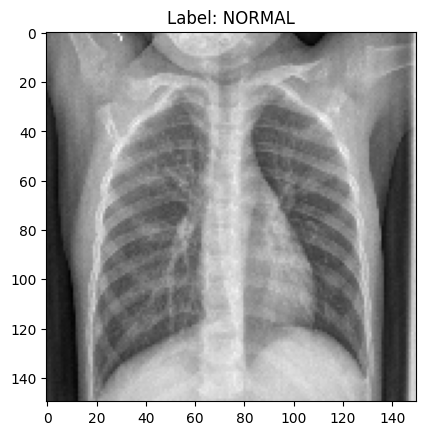

In [ ]:
import os
import zipfile
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Path to the zip file (adjust as necessary)
zip_path =  '/content/train.zip'

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

# Directory path for the extracted files
train_dir = '/content/train'

# Categories
categories = ['COVID', 'NORMAL']

# Function to load images and labels
def load_images_labels(base_dir, categories):
    images = []
    labels = []
    count_dict = {category: 0 for category in categories}

    for category in categories:
        class_num = categories.index(category)
        path = os.path.join(base_dir, category)
        print(f'Processing {category}...')
        for filename in os.listdir(path):
            file_path = os.path.join(path, filename)
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                print(f'Original shape of {filename}: {img.shape}')  # Print shape before resizing
                img = cv2.resize(img, (150, 150))
                images.append(img)
                labels.append(class_num)
                count_dict[category] += 1
        print(f'Loaded {count_dict[category]} images from {category}')

    return np.array(images), np.array(labels), count_dict

# Load images and labels
train_images, train_labels, sample_counts = load_images_labels(train_dir, categories)

# Print dataset details
print('Total images:', len(train_images))
print('Total labels:', len(train_labels))
print('Data type:', train_images.dtype)
print('Shape of image data:', train_images.shape)
print('Shape of label data:', train_labels.shape)
print('Number of COVID samples:', sample_counts['COVID'])
print('Number of NORMAL samples:', sample_counts['NORMAL'])

# Show a few images
for i in range(len(train_images)):
    if train_labels[i] == categories.index('NORMAL'):
        plt.imshow(train_images[i], cmap='gray')
        plt.title('Label: NORMAL')
        plt.show()
        break



##add Agementation for increasing train data (only flliped)

Processing COVID...
Loaded 74 original images and augmented from COVID
Processing NORMAL...
Loaded 74 original images and augmented from NORMAL
Total images: 296
Total labels: 296
Data type: uint8
Shape of image data: (296, 224, 224)
Shape of label data: (296,)
Number of COVID samples: 74
Number of NORMAL samples: 74


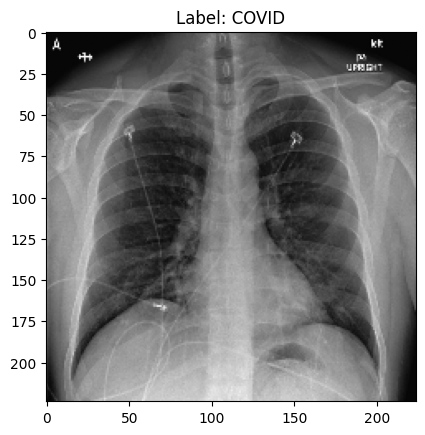

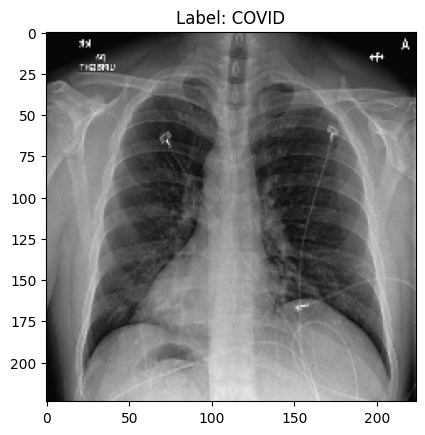

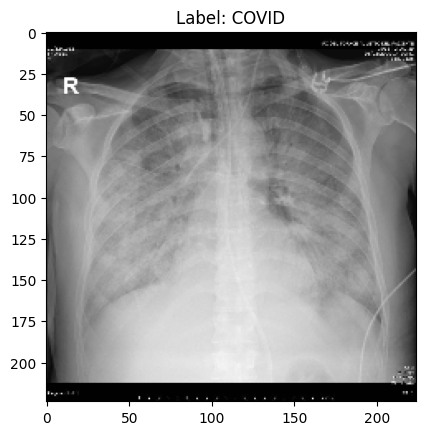

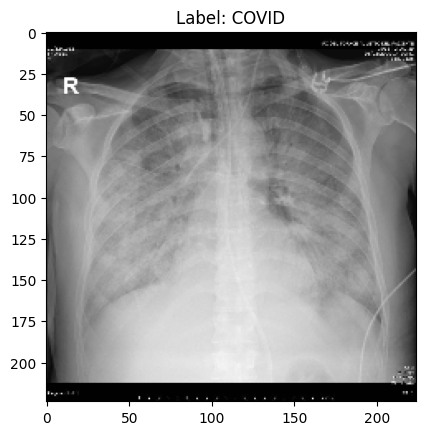

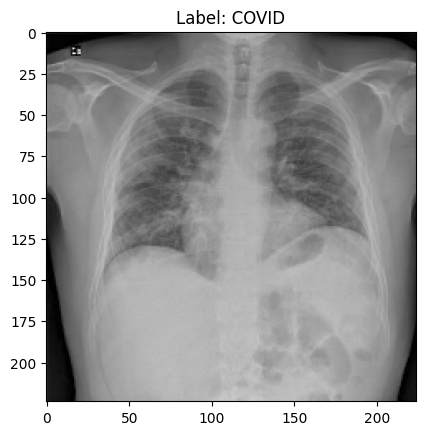

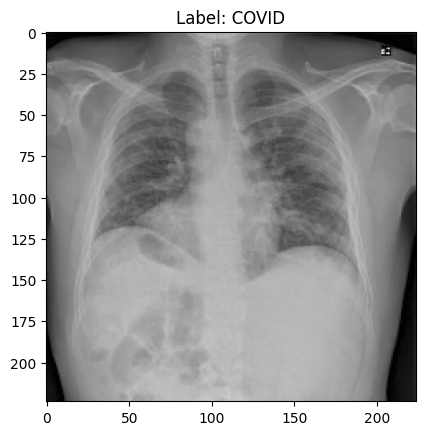

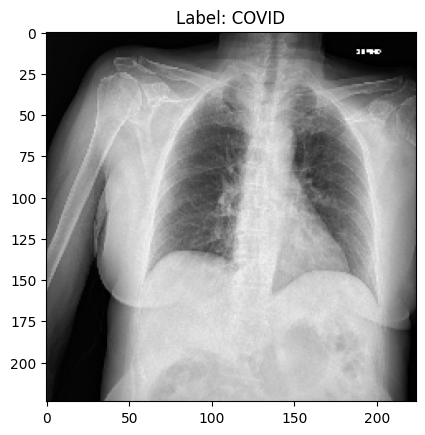

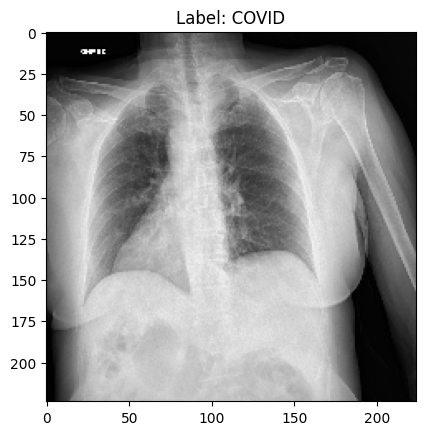

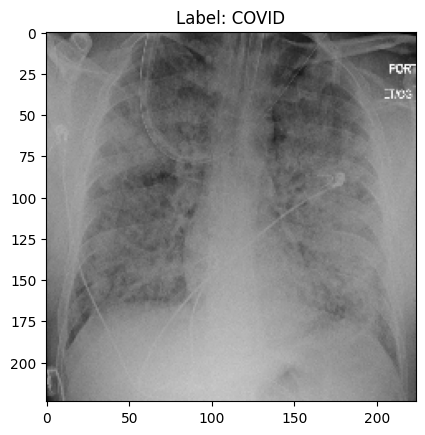

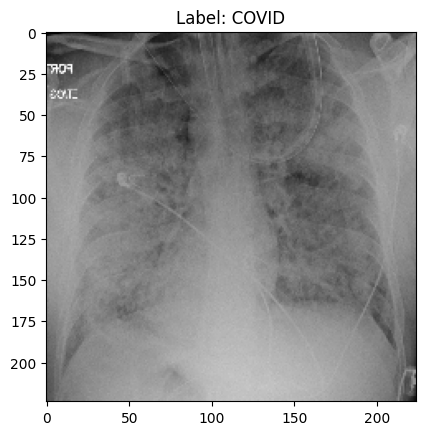

In [ ]:
import os
import zipfile
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Upload the zip file to your Google Colab session first
zip_path = '/content/drive/MyDrive/machine learning - bouns peoject/train.zip'

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

# Set the directory path for the extracted files
train_dir = '/content/train'

# Categories
categories = ['COVID', 'NORMAL']

def augment_image(img):
    # Randomly flip the image horizontally
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)  # 1 means flipping horizontally
    return img

# Function to load images and labels
def load_images_labels(base_dir, categories):
    images = []
    labels = []
    count_dict = {category: 0 for category in categories}  # Dictionary to count samples for each category

    for category in categories:
        class_num = categories.index(category)
        path = os.path.join(base_dir, category)
        print(f'Processing {category}...')
        for filename in os.listdir(path):
            file_path = os.path.join(path, filename)
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Read the image in grayscale
            if img is not None:
                img = cv2.resize(img, (224, 224))
                images.append(img)
                labels.append(class_num)
                count_dict[category] += 1

                # Augment the image
                aug_img = augment_image(img)
                images.append(aug_img)
                labels.append(class_num)

        print(f'Loaded {count_dict[category]} original images and augmented from {category}')

    return np.array(images), np.array(labels), count_dict

# Load images and labels
train_images, train_labels, sample_counts = load_images_labels(train_dir, categories)

# Print the dataset's details
print('Total images:', len(train_images))
print('Total labels:', len(train_labels))
print('Data type:', train_images.dtype)
print('Shape of image data:', train_images.shape)
print('Shape of label data:', train_labels.shape)
print('Number of COVID samples:', sample_counts['COVID'])
print('Number of NORMAL samples:', sample_counts['NORMAL'])

# Show a few images
for i in range(10):  # Show first 10 images
    plt.imshow(train_images[i], cmap='gray')
    plt.title('Label: ' + categories[train_labels[i]])
    plt.show()


## adding all agumentation methods on paper + CNN model

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8628 - loss: 0.3068
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9753 - loss: 0.0766
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9898 - loss: 0.0344
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9942 - loss: 0.0196
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9949 - loss: 0.0141
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9946 - loss: 0.0130
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9985 - loss: 0.0093
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9989 - loss: 0.0059
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9950 - loss: 0.0145
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9953 - loss: 0.0197
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9963 - loss: 0.0098
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy

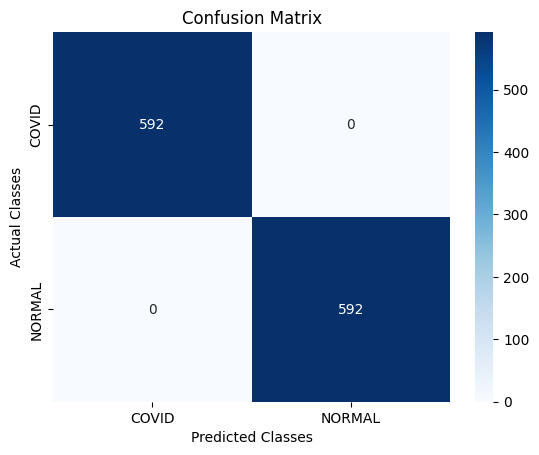

In [ ]:
import os
import zipfile
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt

# Upload the zip file to your Google Colab session first
zip_path = '/content/drive/MyDrive/machine learning - bouns peoject/train.zip'

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

# Set the directory path for the extracted files
train_dir = '/content/train'

# Categories
categories = ['COVID', 'NORMAL']

def rotate_image(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

def augment_image(img):
    aug_images = []
    # Original image
    aug_images.append(img)
    # Flip the image horizontally
    flipped_img = cv2.flip(img, 1)  # 1 means flipping horizontally
    aug_images.append(flipped_img)
    # Rotate 90, 180, 270 degrees
    for angle in [90, 180, 270]:
        aug_images.append(rotate_image(img, angle))
        aug_images.append(rotate_image(flipped_img, angle))  # Also apply rotation to the flipped image
    return aug_images

# Function to load images and labels
def load_images_labels(base_dir, categories):
    images = []
    labels = []
    for category in categories:
        class_num = categories.index(category)
        path = os.path.join(base_dir, category)
        for filename in os.listdir(path):
            file_path = os.path.join(path, filename)
            img = cv2.imread(file_path, cv2.IMREAD_COLOR)
            if img is not None:
                img = cv2.resize(img, (150, 150))
                augmented_imgs = augment_image(img)
                for aug_img in augmented_imgs:
                    images.append(aug_img)
                    labels.append(class_num)

    return np.array(images), np.array(labels)

# Load images and labels
train_images, train_labels = load_images_labels(train_dir, categories)
# print("Shape of train_images before reshaping:", train_images.shape)
train_images = train_images.reshape(-1, 150, 150, 3) / 255.0  # Normalize and reshape the images


# Define the CNN model
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(axis=-1),
    MaxPooling2D((2, 2)),  # 2x2 Max pooling
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(axis=-1),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(axis=-1) ,
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(axis=-1) ,
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
     BatchNormalization(axis=-1) ,
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(axis=-1) ,
    MaxPooling2D((2, 2)),
    BatchNormalization(axis=-1) ,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(axis=-1) ,
    Dense(256, activation='relu'),
    BatchNormalization(axis=-1) ,
    Dense(1, activation='sigmoid')

])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
model.fit(train_images, train_labels, epochs=50, batch_size=32)

# Predict labels
predictions = model.predict(train_images)
predicted_classes = (predictions > 0.5).astype(int).flatten()


true_classes = train_labels.flatten()

# print("True classes:", true_classes)
# print("Type of true_classes:", type(true_classes))
# print("true_classes shape:", true_classes.shape)
# print("predicted_classes shape:", predicted_classes.shape)

# Print classification report
print(classification_report(true_classes, predicted_classes, target_names=categories))

# Plot confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()





##  CNN _(used for agument with flliped method)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 524ms/step - accuracy: 0.8490 - loss: 0.3257
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9444 - loss: 0.1487
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9587 - loss: 0.1359
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9836 - loss: 0.0547
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9922 - loss: 0.0298
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9885 - loss: 0.0296
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9959 - loss: 0.0153
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9708 - loss: 0.0907
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9405 - loss: 0.1619
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9480 - loss: 0.1381
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9776 - loss: 0.1156
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accurac

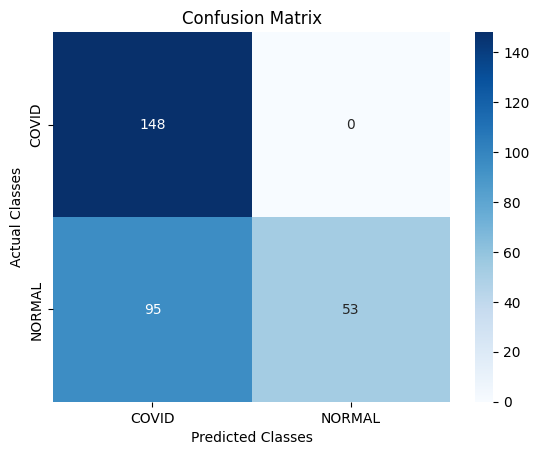

In [ ]:
import os
import zipfile
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt

# Set the path for the zip file and extract it
zip_path = '/content/drive/MyDrive/machine learning - bouns peoject/train.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

train_dir = '/content/train'
categories = ['COVID', 'NORMAL']

def augment_image(img):
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)  # Horizontal flip
    # Add more augmentations if needed
    return img

def load_images_labels(base_dir, categories):
    images = []
    labels = []
    for category in categories:
        class_num = categories.index(category)
        path = os.path.join(base_dir, category)
        for filename in os.listdir(path):
            file_path = os.path.join(path, filename)
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (224, 224))
                images.append(img)
                labels.append(class_num)
                aug_img = augment_image(img)
                images.append(aug_img)
                labels.append(class_num)
    return np.array(images), np.array(labels)

# Load images and labels
train_images, train_labels = load_images_labels(train_dir, categories)
train_images = train_images.reshape(-1, 224, 224, 1) / 255.0  # Normalize and reshape

# Define the model
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_images, train_labels, epochs=50, batch_size=32)

# Predict labels
predictions = model.predict(train_images)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Print classification report
print(classification_report(train_labels, predicted_classes, target_names=categories))

# Plot confusion matrix
conf_matrix = confusion_matrix(train_labels, predicted_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()


##prepare test part _ (useable for both agument method script)

In [ ]:
import os
import zipfile
import cv2
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

# Path to the uploaded test dataset zip file
zip_path = '/content/drive/MyDrive/machine learning - bouns peoject/test.zip'

# Directory where the extracted files will be stored
extract_dir = '/content/test/test/test/test'

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Function to load and preprocess images
def load_and_preprocess_images(base_dir, categories):
    data = {}
    for category in categories:
        class_path = os.path.join(base_dir, category)
        images = []
        filenames = os.listdir(class_path)
        for filename in filenames:
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is not None:
                img = cv2.resize(img, (150, 150))
                img = img.astype(np.float32) / 255.0
                images.append(img)
        data[category] = np.array(images)
    return data

# Categories in the dataset
categories = ['COVID', 'NORMAL']

# Load and preprocess images for each category
test_data = load_and_preprocess_images(extract_dir, categories)

# Print the details of the loaded data
for category, images in test_data.items():
    print(f"Category: {category}")
    print(f"Data type: {images.dtype}")
    print(f"Shape: {images.shape}")


Category: COVID
Data type: float32
Shape: (20, 150, 150, 3)
Category: NORMAL
Data type: float32
Shape: (20, 150, 150, 3)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

       COVID       0.95      1.00      0.98        20
      NORMAL       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



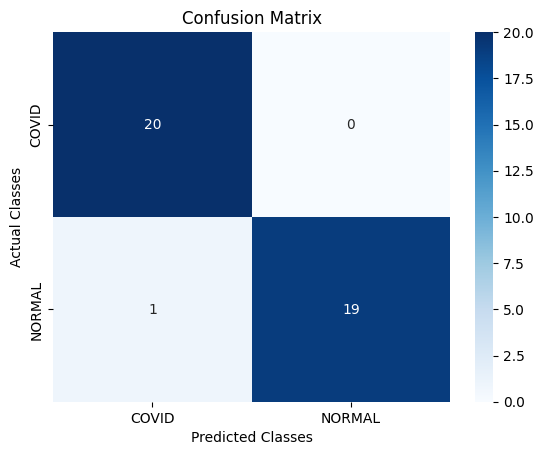

In [ ]:

import os
import zipfile
import cv2
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt

# Path to the uploaded test dataset zip file
zip_path = '/content/drive/MyDrive/machine learning - bouns peoject/test.zip'

# Directory where the extracted files will be stored
extract_dir = '/content/test/test/test/test'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Define the directory path for the extracted files
test_dir = os.path.join(extract_dir, 'test')

# Categories (ensure these are the same as used during training)
categories = ['COVID', 'NORMAL']

# Function to load and preprocess images
def load_images_labels(base_dir, categories):
    images = []
    labels = []
    for category in categories:
        class_num = categories.index(category)
        path = os.path.join(base_dir, category)
        for filename in os.listdir(path):
            file_path = os.path.join(path, filename)
            img = cv2.imread(file_path, cv2.IMREAD_COLOR)  # Load in RGB color mode
            if img is not None:
                img = cv2.resize(img, (150, 150))  # Resize to match the model's input size
                img = img.astype(np.float32) / 255.0  # Normalize pixel values to [0, 1]
                images.append(img)
                labels.append(class_num)
    return np.array(images), np.array(labels)

# Load and preprocess the test data
test_images, test_labels = load_images_labels(test_dir, categories)

# Predict the labels for the test data
predictions = model.predict(test_images)
predicted_classes = (predictions > 0.5).astype(int).flatten()  # Convert probabilities to binary labels

# Assuming test_labels are already in the correct format (0 or 1) and not one-hot encoded
true_classes = test_labels.flatten()

# Print classification report
clsrpt = classification_report(true_classes, predicted_classes, target_names=categories)
print(clsrpt)

# Plot confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()


# Q_1 TransformerFFT

In [ ]:
import os
os.chdir('/content/drive/MyDrive/machine learning - bouns peoject/iTransformer-main/iTransformer-main')
# Install the package
!pip install .


Processing /content/drive/MyDrive/machine learning - bouns peoject/iTransformer-main/iTransformer-main
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.1

In [ ]:
!pip install library-name


ERROR: Could not find a version that satisfies the requirement library-name (from versions: none)
ERROR: No matching distribution found for library-name


In [ ]:
!pip install beartype


In [ ]:
import pandas as pd

# Load the data from the uploaded file
file_path = '/content/drive/MyDrive/machine learning - bouns peoject/exchange_rate.txt.gz'
data = pd.read_csv(file_path, compression='gzip', header=None)

# Display the first few rows and the data info
print(data.head())
print(data.info())


        0       1         2         3         4         5       6         7
0  0.7855  1.6110  0.861698  0.634196  0.211242  0.006838  0.5930  0.525486
1  0.7818  1.6100  0.861104  0.633513  0.211242  0.006863  0.5940  0.523972
2  0.7867  1.6293  0.861030  0.648508  0.211242  0.006975  0.5973  0.526316
3  0.7860  1.6370  0.862069  0.650618  0.211242  0.006953  0.5970  0.523834
4  0.7849  1.6530  0.861995  0.656254  0.211242  0.006940  0.5985  0.527426
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       7588 non-null   float64
 1   1       7588 non-null   float64
 2   2       7588 non-null   float64
 3   3       7588 non-null   float64
 4   4       7588 non-null   float64
 5   5       7588 non-null   float64
 6   6       7588 non-null   float64
 7   7       7588 non-null   float64
dtypes: float64(8)
memory usage: 474.4 KB
None


Epoch 1: Train Loss = 0.3047, Test Loss = 0.2425
Epoch 2: Train Loss = 0.0812, Test Loss = 0.1196
Epoch 3: Train Loss = 0.0457, Test Loss = 0.0979
Epoch 4: Train Loss = 0.0410, Test Loss = 0.0879
Epoch 5: Train Loss = 0.0367, Test Loss = 0.0677
Epoch 6: Train Loss = 0.0276, Test Loss = 0.0441
Epoch 7: Train Loss = 0.0213, Test Loss = 0.0339
Epoch 8: Train Loss = 0.0188, Test Loss = 0.0299
Epoch 9: Train Loss = 0.0177, Test Loss = 0.0301
Epoch 10: Train Loss = 0.0172, Test Loss = 0.0323
Epoch 11: Train Loss = 0.0169, Test Loss = 0.0297
Epoch 12: Train Loss = 0.0167, Test Loss = 0.0298
Epoch 13: Train Loss = 0.0166, Test Loss = 0.0310
Epoch 14: Train Loss = 0.0164, Test Loss = 0.0307
Epoch 15: Train Loss = 0.0163, Test Loss = 0.0300
Epoch 16: Train Loss = 0.0162, Test Loss = 0.0304
Epoch 17: Train Loss = 0.0160, Test Loss = 0.0313
Epoch 18: Train Loss = 0.0159, Test Loss = 0.0316
Epoch 19: Train Loss = 0.0157, Test Loss = 0.0322
Epoch 20: Train Loss = 0.0155, Test Loss = 0.0334
Epoch 21:

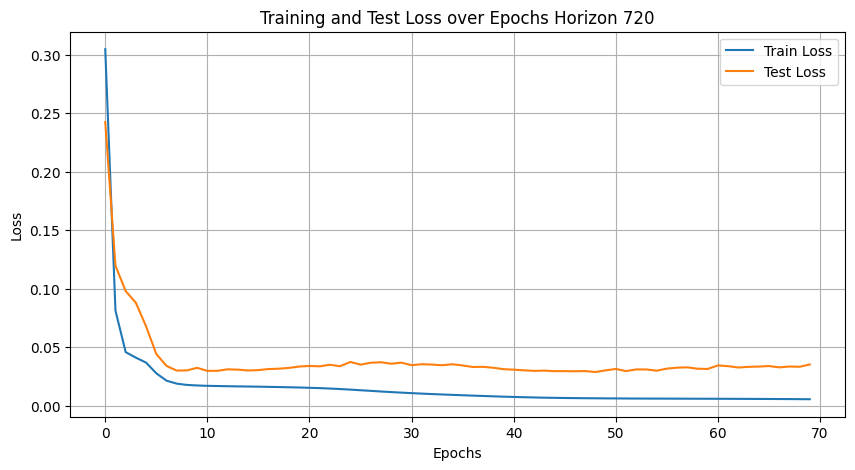

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 🔹 Prepare and Scale Data with Horizon
# ---------------------------------------------------
def prepare_and_scale_data(data, lookback, horizon):
    scaler_X = MinMaxScaler()
    data_scaled = scaler_X.fit_transform(data)

    sequences = []
    targets = []

    for i in range(lookback, len(data_scaled) - horizon):
        sequences.append(data_scaled[i - lookback:i])
        targets.append(data_scaled[i:i + horizon])  # Predicting multiple time steps

    train_size = int(0.8 * len(sequences))
    X_train, X_test = sequences[:train_size], sequences[train_size:]
    y_train, y_test = targets[:train_size], targets[train_size:]

    return np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test), scaler_X

# Load and preprocess dataset
# file_path = '/mnt/data/exchange_rate.txt.gz'
df = pd.read_csv(file_path, compression='gzip', header=None)

# Define Lookback and Horizon
LOOKBACK = 10  # Past time steps
HORIZON = 720  # Future time steps

X_train, X_test, y_train, y_test, scaler_X = prepare_and_scale_data(df.values, LOOKBACK, HORIZON)

# Convert to PyTorch tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ---------------------------------------------------
# 🔹 Scaled Dot-Product Attention Without nn.MultiheadAttention
# ---------------------------------------------------
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dim_head):
        super().__init__()
        self.scale = dim_head ** -0.5

    def forward(self, Q, K, V):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attn_probs = torch.softmax(attn_scores, dim=-1)
        return torch.matmul(attn_probs, V)

# ---------------------------------------------------
# 🔹 Multi-Head Self-Attention With Horizon
# ---------------------------------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.heads = heads
        self.dim_head = dim // heads

        self.to_Q = nn.Linear(dim, dim, bias=False)
        self.to_K = nn.Linear(dim, dim, bias=False)
        self.to_V = nn.Linear(dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim)

        self.attention = ScaledDotProductAttention(self.dim_head)

    def forward(self, x):
        batch, seq_len, dim = x.shape

        Q = self.to_Q(x).view(batch, seq_len, self.heads, self.dim_head).transpose(1, 2)
        K = self.to_K(x).view(batch, seq_len, self.heads, self.dim_head).transpose(1, 2)
        V = self.to_V(x).view(batch, seq_len, self.heads, self.dim_head).transpose(1, 2)

        out = self.attention(Q, K, V)
        out = out.transpose(1, 2).reshape(batch, seq_len, dim)

        return self.to_out(out)

# ---------------------------------------------------
# 🔹 Feedforward Network (FFN)
# ---------------------------------------------------
class FeedForward(nn.Module):
    def __init__(self, dim, expansion=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * expansion),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * expansion, dim)
        )

    def forward(self, x):
        return self.net(x)

# ---------------------------------------------------
# 🔹 Transformer Encoder Layer With Horizon
# ---------------------------------------------------
class TransformerEncoderLayer(nn.Module):
    def __init__(self, dim, heads, expansion=4, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(dim, heads)
        self.ffn = FeedForward(dim, expansion, dropout)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ffn(x))
        return x

# ---------------------------------------------------
# 🔹 Stacked Transformer Encoder Model With Horizon
# ---------------------------------------------------
class iTransformer(nn.Module):
    def __init__(self, num_layers, dim, heads, horizon, expansion=4, dropout=0.1):
        super().__init__()
        self.horizon = horizon
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(dim, heads, expansion, dropout) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(dim, dim * horizon)  # Predicting multiple future steps

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.fc_out(x[:, -1, :])  # Last time step
        return x.view(x.shape[0], self.horizon, -1)  # Reshape for Horizon output

# ---------------------------------------------------
# 🔹 Train the Transformer Model With Horizon
# ---------------------------------------------------
model = iTransformer(num_layers=4, dim=8, heads=2, horizon=HORIZON)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, num_epochs):
    train_losses, test_losses = [], []

    for epoch in range(num_epochs):
        total_train_loss = 0
        model.train()
        for data, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for data, targets in test_loader:
                outputs = model(data)
                loss = criterion(outputs, targets)
                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

    return train_losses, test_losses

train_losses, test_losses = train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, num_epochs=70)

# ---------------------------------------------------
# 🔹 Plot Training and Test Losses
# ---------------------------------------------------
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss over Epochs Horizon 720')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_losses(train_losses, test_losses)


In [ ]:
import math

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load the data
# file_path = '/mnt/data/exchange_rate.txt.gz'
data = pd.read_csv(file_path, compression='gzip', header=None)  # Adjust if the file has a header

# Display the first few rows of the dataset to understand its structure
print("First few rows of the dataset:")
print(data.head())

# Describe the data to get more insight
print("\nData Description:")
print(data.describe())

# Check for any missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

# Normalize the data
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data.iloc[:, :-1])  # Assuming the last column is the target

# Split the data into training and testing sets
train_data, test_data = train_test_split(data_normalized, test_size=0.3, random_state=42)

# Convert to PyTorch tensors
train_tensors = torch.tensor(train_data, dtype=torch.float32)
test_tensors = torch.tensor(test_data, dtype=torch.float32)

# Assume you are using all columns except the last as features
X_train = train_tensors[:, :-1]
y_train = train_tensors[:, -1]
X_test = test_tensors[:, :-1]
y_test = test_tensors[:, -1]

# Create Tensor Datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader setup
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("\nShapes of train and test sets:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


First few rows of the dataset:
        0       1         2         3         4         5       6         7
0  0.7855  1.6110  0.861698  0.634196  0.211242  0.006838  0.5930  0.525486
1  0.7818  1.6100  0.861104  0.633513  0.211242  0.006863  0.5940  0.523972
2  0.7867  1.6293  0.861030  0.648508  0.211242  0.006975  0.5973  0.526316
3  0.7860  1.6370  0.862069  0.650618  0.211242  0.006953  0.5970  0.523834
4  0.7849  1.6530  0.861995  0.656254  0.211242  0.006940  0.5985  0.527426

Data Description:
                 0            1            2            3            4  \
count  7588.000000  7588.000000  7588.000000  7588.000000  7588.000000   
mean      0.776974     1.634105     0.821811     0.848146     0.142833   
std       0.136620     0.161544     0.117123     0.168874     0.023996   
min       0.483297     1.211534     0.618582     0.548617     0.109292   
25%       0.701422     1.532887     0.727901     0.696864     0.120814   
50%       0.761377     1.606574     0.811582     0